# 🍷 NLP em Regressão: Previsão de Pontuação de Vinhos

Este experimento explora como utilizar técnicas de Processamento de Linguagem Natural (NLP) para resolver problemas de **Regressão**. Ao invés de classificar sentimentos (Positivo/Negativo), vamos prever uma **variável contínua** (a nota de 80 a 100 de um vinho) baseando-nos puramente na descrição escrita por um sommelier.

**Dataset:** Wine Reviews (Kaggle)
**Métricas de Regressão:** MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), R² (Coeficiente de Determinação).
**Princípios MLOps:** Rastreamento total via MLflow.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

# Configurar MLflow para usar o diretório raiz do projeto
mlflow.set_tracking_uri("sqlite:///../../mlruns.db")
mlflow.set_experiment("NLP_Regression_Wine_Points")

plt.style.use('dark_background')


2026/07/29 11:21:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/07/29 11:21:36 INFO mlflow.store.db.utils: Updating database tables


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step


...

INFO  [alembic.runtime.migration] Running upgrade 5b0e9adcef9c -> 4465047574b1, increase max dataset schema size


INFO  [alembic.runtime.migration] Running upgrade 4465047574b1 -> f5a4f2784254, increase run tag value limit to 8000


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


2026/07/29 11:21:41 INFO mlflow.tracking.fluent: Experiment with name 'NLP_Regression_Wine_Points' does not exist. Creating a new experiment.


## 1. Coleta de Dados via KaggleHub

In [2]:
# Fazendo download do dataset
path = kagglehub.dataset_download("zynicide/wine-reviews")

print("Dataset baixado em:", path)
csv_file = os.path.join(path, "winemag-data-130k-v2.csv")

# Carregando os dados
df = pd.read_csv(csv_file, index_col=0)
print(f"Tamanho original do dataset: {df.shape}")
df.head(3)


Dataset baixado em: C:\Users\pedro\.cache\kagglehub\datasets\zynicide\wine-reviews\versions\4


Tamanho original do dataset: (129971, 13)


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm


## 2. Pré-processamento (NLP e Variável Target)

Tamanho do dataset limpo: (119955, 2)


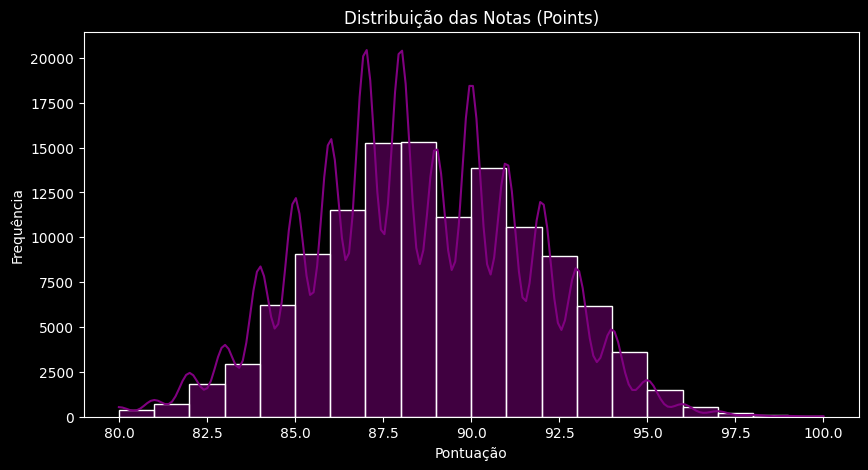

In [3]:
# Selecionar apenas a descrição e a pontuação
df = df[['description', 'points']].dropna()

# Remover descrições duplicadas para evitar vazamento de dados
df = df.drop_duplicates(subset=['description'])

print(f"Tamanho do dataset limpo: {df.shape}")

# Analisando a distribuição da variável contínua Target (Points)
plt.figure(figsize=(10, 5))
sns.histplot(df['points'], bins=20, kde=True, color='purple')
plt.title('Distribuição das Notas (Points)')
plt.xlabel('Pontuação')
plt.ylabel('Frequência')
plt.savefig('target_distribution.png')
plt.show()


## 3. Vetorização (TF-IDF) e Train-Test Split

In [4]:
X = df['description']
y = df['points']

# Utilizando TF-IDF com n-grams (1,2) para capturar o contexto da linguagem do vinho
print("Vetorizando o texto (TF-IDF)...")
vectorizer = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1, 2))
X_vectorized = vectorizer.fit_transform(X)

print(f"Shape da Matriz Esparsa: {X_vectorized.shape}")

X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

# Salvar o vetorizador localmente como um artefato MLOps
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')


Vetorizando o texto (TF-IDF)...


Shape da Matriz Esparsa: (119955, 15000)


['tfidf_vectorizer.pkl']

## 4. Função MLOps para Treinamento e Registro (MLflow)

In [5]:
def train_and_log_model(model_name, model, X_tr, y_tr, X_te, y_te, params=None):
    with mlflow.start_run(run_name=model_name):
        # Treinamento
        print(f"Treinando {model_name}...")
        model.fit(X_tr, y_tr)
        
        # Predição
        y_pred = model.predict(X_te)
        
        # Métricas de Regressão
        mae = mean_absolute_error(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2 = r2_score(y_te, y_pred)
        
        print(f"Resultados {model_name}:")
        print(f"MAE:  {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²:   {r2:.4f}")
        
        # Registro MLOps
        mlflow.set_tag("model_type", "Regression")
        mlflow.set_tag("nlp_technique", "TF-IDF")
        mlflow.log_param("max_features", 15000)
        mlflow.log_param("ngram_range", "(1, 2)")
        
        if params:
            mlflow.log_params(params)
            
        mlflow.log_metrics({"MAE": mae, "RMSE": rmse, "R2": r2})
        
        # Registrar o modelo
        if 'LGBM' in model_name:
            mlflow.lightgbm.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")
            
        # Registrar artefatos adicionais
        mlflow.log_artifact('tfidf_vectorizer.pkl')
        mlflow.log_artifact('target_distribution.png')
        
        # Gráfico Real vs Previsto
        plt.figure(figsize=(8, 8))
        plt.scatter(y_te, y_pred, alpha=0.1, color='cyan')
        plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
        plt.xlabel('Real Points')
        plt.ylabel('Predicted Points')
        plt.title(f'{model_name}: Real vs Predicted')
        plt.savefig('real_vs_predicted.png')
        mlflow.log_artifact('real_vs_predicted.png')
        plt.close()
        
        return model, mae, rmse, r2


## 5. Treinando Modelo Baseline: Ridge Regression

In [6]:
ridge_params = {'alpha': 1.0, 'random_state': 42}
ridge_model = Ridge(**ridge_params)

model_ridge, mae_r, rmse_r, r2_r = train_and_log_model(
    "Ridge_Regression_TFIDF", ridge_model, X_train, y_train, X_test, y_test, params=ridge_params
)


Treinando Ridge_Regression_TFIDF...


Resultados Ridge_Regression_TFIDF:
MAE:  1.3314
RMSE: 1.6936
R²:   0.6992


2026/07/29 11:21:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


## 6. Treinando Modelo Árvores Otimizadas: LightGBM

In [7]:
lgbm_params = {
    'n_estimators': 300,
    'learning_rate': 0.1,
    'max_depth': 8,
    'random_state': 42,
    'n_jobs': -1
}
lgbm_model = LGBMRegressor(**lgbm_params)

model_lgbm, mae_l, rmse_l, r2_l = train_and_log_model(
    "LightGBM_Regression_TFIDF", lgbm_model, X_train, y_train, X_test, y_test, params=lgbm_params
)


Treinando LightGBM_Regression_TFIDF...


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.966889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623091
[LightGBM] [Info] Number of data points in the train set: 95964, number of used features: 14998
[LightGBM] [Info] Start training from score 88.440707


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Resultados LightGBM_Regression_TFIDF:
MAE:  1.4764
RMSE: 1.8726
R²:   0.6323


2026/07/29 11:22:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


## 7. Conclusão MLOps

Em problemas de regressão textual, **Modelos Lineares Regularizados (como o Ridge)** frequentemente superam ou empatam tecnicamente com árvores complexas (LightGBM) quando a dimensionalidade do TF-IDF é muito alta, além de serem ordens de magnitude mais rápidos no treinamento. 

Avaliamos as notas dos vinhos baseadas puramente no vocabulário usado pelos especialistas, extraindo a correlação direta entre o jargão (ex: "magnificent", "complex", "fruity") e a pontuação técnica!
